# Toy Inference From Run Directory

Interactive notebook version for continuing development.

Workflow:
1. Set `RUN_DIR` and toy physical inputs.
2. Load `train_config_used.json`, `scaler_state.json`, and checkpoint.
3. Build scaled toy features.
4. Run inference and plot mean plus `+/- 1 std`.

In [2]:
from pathlib import Path
from __future__ import annotations

import json

from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn


In [43]:
# User config
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "MLP").exists() and PROJECT_ROOT.name == "MLP":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUN_DIR = PROJECT_ROOT / "MLP" / "runs_mlp" / "stage2_NLL_penetration_20260317_194155"


toy_raw = {
    "tilt_angle_radian": float(np.deg2rad(20.0)),
    "plumes": 10.0,
    "diameter_mm": 0.355,
    "injection_duration_us": 1000.0,
    "injection_pressure_bar": 2000.0,
    "chamber_pressure_bar": 25.0,
    "control_backpressure_bar": 4.0,
}

toy_n_points = 300
toy_time_ms = np.linspace(0.0, 5.0, toy_n_points, dtype=np.float32)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# 2D solver Macro 
t = 0.5 # ms
cone_angle = 20 # deg, change to a function in the future

cylinder_radius = 120 # mm
cylinder_height = 60 # mm

right_padding = 10 # mm
bottom_padding = 10 # mm

grid_size = 1 # mm

cylinder_head_offset = 50 # mm, improve to parametrized function later

assert cylinder_head_offset <= cylinder_height

In [44]:

x = np.linspace(0, cylinder_radius + right_padding, (cylinder_radius + right_padding)//grid_size, endpoint=False)
y = np.linspace(0, cylinder_height + bottom_padding, (cylinder_height + bottom_padding)//grid_size, endpoint=False)

X, Y = np.meshgrid(x, y, indexing ='ij')


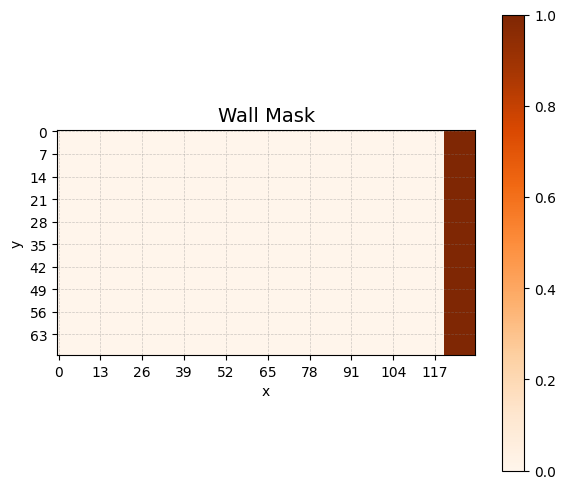

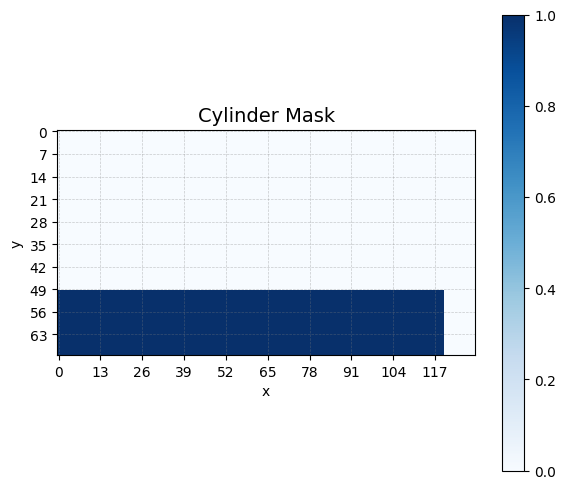

In [45]:
import numpy as np
import matplotlib.pyplot as plt

canvas = np.zeros((
    (cylinder_height + bottom_padding) // grid_size,   # H
    (cylinder_radius + right_padding) // grid_size     # W
))

wall_mask = np.zeros_like(canvas)
wall_mask[:, cylinder_radius // grid_size:] = 1

cylinder_mask = np.zeros_like(canvas)
cylinder_mask[cylinder_head_offset // grid_size:, :cylinder_radius // grid_size] = 1


def show_mask(mask, title, cmap="Blues"):
    h, w = mask.shape
    fig, ax = plt.subplots(figsize=(6, 6))

    im = ax.imshow(
        mask,
        cmap=cmap,
        # origin="lower",   # 比较像一般 x-y 坐标
        interpolation="none"
    )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

    ax.set_xticks(np.arange(0, w, max(1, w // 10)))
    ax.set_yticks(np.arange(0, h, max(1, h // 10)))

    ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.4)
    plt.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.show()


show_mask(wall_mask, "Wall Mask", cmap="Oranges")
show_mask(cylinder_mask, "Cylinder Mask", cmap="Blues")



In [46]:
def make_activation(name: str) -> nn.Module:
    name = (name or "relu").lower()
    if name == "relu":
        return nn.ReLU()
    if name == "gelu":
        return nn.GELU()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"Unsupported activation '{name}'")


class PenetrationMLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        *,
        activation: str = "relu",
        dropout: float = 0.0,
    ) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        in_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend(
                [
                    nn.Linear(in_dim, hidden_dim),
                    nn.LayerNorm(hidden_dim),
                    make_activation(activation),
                ]
            )
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = hidden_dim
        layers.append(nn.Linear(in_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def split_mu_logvar(model_output: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    mu, log_var = model_output.chunk(2, dim=-1)
    return mu, log_var


def resolve_model_path(run_dir: Path) -> Path:
    for name in ("best_model_stage2.pt", "best_model_stage1.pt"):
        model_path = run_dir / name
        if model_path.exists():
            return model_path
    raise FileNotFoundError(f"No supported model checkpoint found under: {run_dir}")


def zscore_from_state(value: float, z_col: str, scaler_state: dict[str, Any]) -> float:
    stats = scaler_state["zscore"][z_col]
    return (float(value) - float(stats["mean"])) / (float(stats["std"]) + 1e-12)


def build_toy_feature_matrix(
    raw: dict[str, float],
    time_ms: np.ndarray,
    scaler_state: dict[str, Any],
    feature_columns: list[str],
    time_feature: str,
) -> np.ndarray:
    p_inj = float(raw["injection_pressure_bar"])
    p_ch = float(raw["chamber_pressure_bar"])
    delta_p = max(p_inj - p_ch, 1e-6)

    time_min_ms = float(scaler_state["time"]["min_ms"])
    time_max_ms = float(scaler_state["time"]["max_ms"])
    time_span_ms = max(time_max_ms - time_min_ms, 1e-12)
    time_norm = np.clip((time_ms - time_min_ms) / time_span_ms, 0.0, 1.0).astype(np.float32)

    feature_series: dict[str, np.ndarray] = {
        time_feature: time_norm,
        "tilt_angle_radian_z": np.full_like(
            time_norm,
            zscore_from_state(raw["tilt_angle_radian"], "tilt_angle_radian_z", scaler_state),
            dtype=np.float32,
        ),
        "plumes_z": np.full_like(
            time_norm,
            zscore_from_state(raw["plumes"], "plumes_z", scaler_state),
            dtype=np.float32,
        ),
        "diameter_mm_z": np.full_like(
            time_norm,
            zscore_from_state(raw["diameter_mm"], "diameter_mm_z", scaler_state),
            dtype=np.float32,
        ),
        "injection_duration_us_z": np.full_like(
            time_norm,
            zscore_from_state(raw["injection_duration_us"], "injection_duration_us_z", scaler_state),
            dtype=np.float32,
        ),
        "log_injection_pressure_bar_z": np.full_like(
            time_norm,
            zscore_from_state(np.log(p_inj), "log_injection_pressure_bar_z", scaler_state),
            dtype=np.float32,
        ),
        "log_chamber_pressure_bar_z": np.full_like(
            time_norm,
            zscore_from_state(np.log(max(p_ch, 1e-6)), "log_chamber_pressure_bar_z", scaler_state),
            dtype=np.float32,
        ),
        "log_delta_pressure_bar_z": np.full_like(
            time_norm,
            zscore_from_state(np.log(delta_p), "log_delta_pressure_bar_z", scaler_state),
            dtype=np.float32,
        ),
        "control_backpressure_bar_z": np.full_like(
            time_norm,
            zscore_from_state(raw["control_backpressure_bar"], "control_backpressure_bar_z", scaler_state),
            dtype=np.float32,
        ),
    }

    columns: list[np.ndarray] = []
    for name in feature_columns:
        if name not in feature_series:
            raise KeyError(f"Unsupported feature column in config: {name}")
        columns.append(feature_series[name])
    return np.column_stack(columns).astype(np.float32)

In [47]:
config_path = RUN_DIR / "train_config_used.json"
scaler_path = RUN_DIR / "scaler_state.json"
model_path = resolve_model_path(RUN_DIR)

with config_path.open("r", encoding="utf-8") as f:
    train_config = json.load(f)
with scaler_path.open("r", encoding="utf-8") as f:
    scaler_state = json.load(f)

feature_columns = list(train_config["feature_columns"])
time_feature = str(train_config.get("time_feature", "time_norm_0_5ms"))

model = PenetrationMLP(
    input_dim=int(train_config["input_dim"]),
    hidden_dims=[int(x) for x in train_config["hidden_dims"]],
    output_dim=int(train_config["output_dim"]),
    activation=str(train_config.get("activation", "relu")),
    dropout=float(train_config.get("dropout", 0.0)),
)
state = torch.load(model_path, map_location=DEVICE)
model.load_state_dict(state)
model.to(DEVICE)
model.eval()

print(f"RUN_DIR: {RUN_DIR.resolve()}")
print(f"Model checkpoint: {model_path.name}")
print(f"Device: {DEVICE}")
print(f"Feature dimension: {len(feature_columns)}")

RUN_DIR: C:\Users\Jiang\Documents\Mie_Postprocessing_Py\MLP\runs_mlp\stage2_NLL_penetration_20260317_194155
Model checkpoint: best_model_stage1.pt
Device: cuda
Feature dimension: 9


In [48]:
toy_features_np = build_toy_feature_matrix(
    raw=toy_raw,
    time_ms=toy_time_ms,
    scaler_state=scaler_state,
    feature_columns=feature_columns,
    time_feature=time_feature,
)
toy_features = torch.as_tensor(toy_features_np, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    toy_out = model(toy_features)
    toy_mu, toy_log_var = split_mu_logvar(toy_out)

toy_mu_np = toy_mu.detach().cpu().numpy().reshape(-1)
toy_log_var_np = toy_log_var.detach().cpu().numpy().reshape(-1)
std_floor = float(train_config.get("std_clamp_min", 0.0))
toy_std_np = np.maximum(np.sqrt(np.exp(toy_log_var_np)), std_floor)
toy_upper_np = toy_mu_np + toy_std_np
toy_lower_np = toy_mu_np - toy_std_np

print("Toy inference completed with feature shape:", toy_features_np.shape)
print("Expected feature dimension:", len(feature_columns))
print("Predicted std range:", float(np.min(toy_std_np)), float(np.max(toy_std_np)))

Toy inference completed with feature shape: (300, 9)
Expected feature dimension: 9
Predicted std range: 6.266425132751465 15.150980949401855


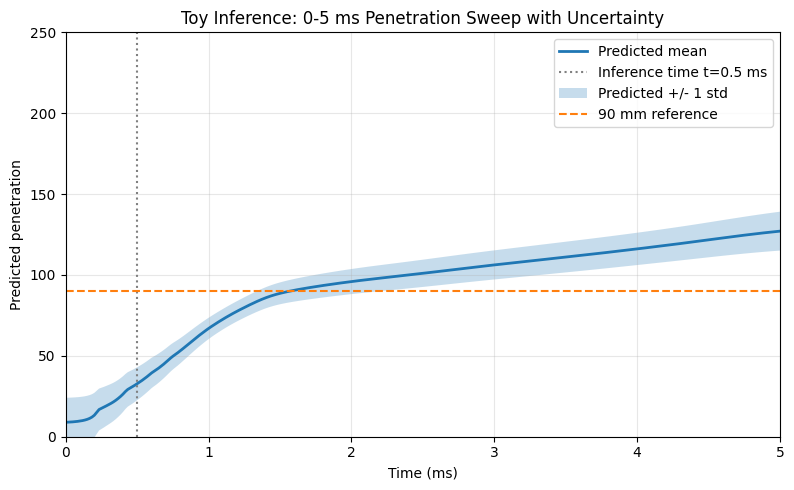

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(toy_time_ms, toy_mu_np, linewidth=2, label="Predicted mean")
plt.axvline(t, color="gray", linestyle=":", label=f"Inference time t={t} ms")
plt.fill_between(toy_time_ms, toy_lower_np, toy_upper_np, alpha=0.25, label="Predicted +/- 1 std")
plt.plot(toy_time_ms, 90 * np.ones_like(toy_time_ms), linestyle="--", label="90 mm reference")
plt.xlabel("Time (ms)")
plt.ylabel("Predicted penetration")
plt.title("Toy Inference: 0-5 ms Penetration Sweep with Uncertainty")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.ylim(0, 250)
plt.xlim(0, 5)
plt.show()

In [50]:
# ========================================
# Calculate the penetration and log variance at a certain time point
# ========================================
toy_features_np = build_toy_feature_matrix(
    raw=toy_raw,
    time_ms=t, # given time
    scaler_state=scaler_state,
    feature_columns=feature_columns,
    time_feature=time_feature,
)

toy_features = torch.as_tensor(toy_features_np, dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    toy_out = model(toy_features)
    toy_mu, toy_log_var = split_mu_logvar(toy_out)

toy_mu_np = toy_mu.detach().cpu().numpy().reshape(-1)
toy_log_var_np = toy_log_var.detach().cpu().numpy().reshape(-1)
std_floor = float(train_config.get("std_clamp_min", 0.0))
toy_std_np = np.maximum(np.sqrt(np.exp(toy_log_var_np)), std_floor)
toy_upper_np = toy_mu_np + toy_std_np
toy_lower_np = toy_mu_np - toy_std_np


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


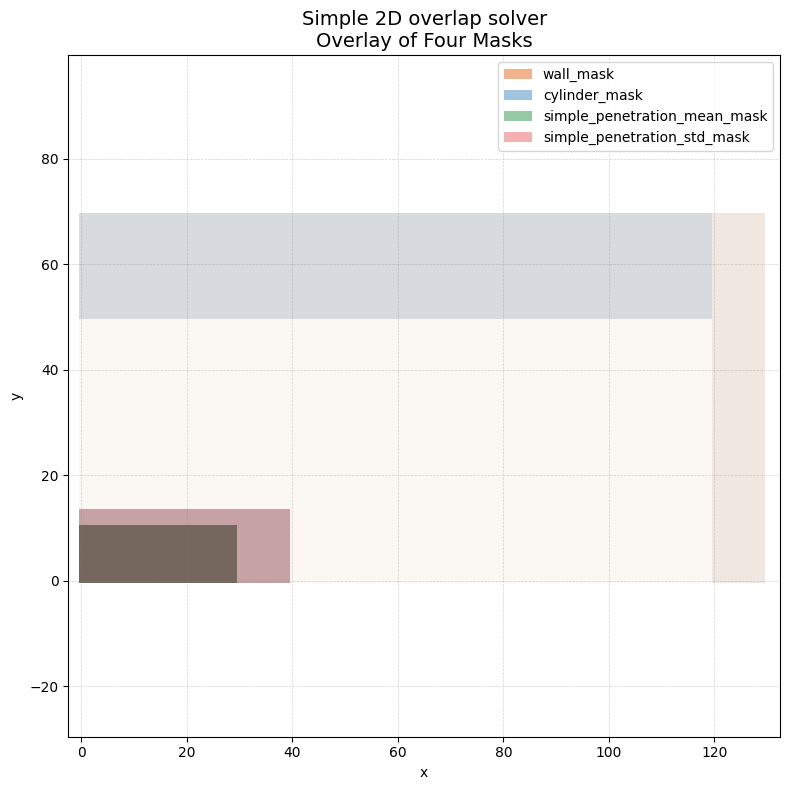

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Draw toy masks
tilt = toy_raw["tilt_angle_radian"]
x_factor = np.cos(tilt)
y_factor = np.sin(tilt)

penetration_x_mean = toy_mu_np.item() * x_factor
penetration_y_mean = toy_mu_np.item() * y_factor

penetration_x_1std = toy_upper_np.item() * x_factor
penetration_y_1std = toy_upper_np.item() * y_factor

# 注意: imshow 对应 mask[y, x]，所以 shape / slice 都是 [H, W] = [y, x]
mean_x = max(0, int(penetration_x_mean) // grid_size)
mean_y = max(0, int(penetration_y_mean) // grid_size)

std_x = max(0, int(penetration_x_1std) // grid_size)
std_y = max(0, int(penetration_y_1std) // grid_size)

simple_penetration_mean_mask = np.zeros_like(canvas)
simple_penetration_mean_mask[:mean_y, :mean_x] = 1.0

simple_penetration_std_mask = np.zeros_like(canvas)
simple_penetration_std_mask[:std_y, :std_x] = 1.0

fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(wall_mask, cmap="Oranges", origin="lower", interpolation="none", alpha=0.45)
ax.imshow(cylinder_mask, cmap="Blues", origin="lower", interpolation="none", alpha=0.45)
ax.imshow(simple_penetration_mean_mask, cmap="Greens", origin="lower", interpolation="none", alpha=0.50)
ax.imshow(simple_penetration_std_mask, cmap="Reds", origin="lower", interpolation="none", alpha=0.35)

h, w = canvas.shape
ax.set_title("Simple 2D overlap solver\nOverlay of Four Masks", fontsize=14)
ax.set_xlabel("x")
ax.set_ylabel("y")

ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.35)

legend_handles = [
    Patch(facecolor=plt.cm.Oranges(0.7), edgecolor="none", alpha=0.45, label="wall_mask"),
    Patch(facecolor=plt.cm.Blues(0.7), edgecolor="none", alpha=0.45, label="cylinder_mask"),
    Patch(facecolor=plt.cm.Greens(0.7), edgecolor="none", alpha=0.50, label="simple_penetration_mean_mask"),
    Patch(facecolor=plt.cm.Reds(0.7), edgecolor="none", alpha=0.35, label="simple_penetration_std_mask"),
]
ax.legend(handles=legend_handles, loc="upper right")
ax.axis("equal")
ax.set_xlim(0, cylinder_radius + right_padding)
ax.set_ylim(0, cylinder_height + bottom_padding)
plt.tight_layout()
plt.show()


In [52]:
simple_wall_collision = (simple_penetration_mean_mask == 1) & (wall_mask == 1)
print("Simple wall collision area (mm^2):", np.sum(simple_wall_collision) * (grid_size ** 2))
simple_cylinder_collision = (cylinder_mask == 1) & (simple_penetration_mean_mask == 1)
print("Simple cylinder collision area (mm^2):", np.sum(simple_cylinder_collision) * (grid_size ** 2))

Simple wall collision area (mm^2): 0
Simple cylinder collision area (mm^2): 0


In [53]:
simple_wall_collision_std = (simple_penetration_std_mask == 1) & (wall_mask == 1)
print("Simple wall collision area with +1 std length (mm^2):", np.sum(simple_wall_collision_std) * (grid_size ** 2))
simple_cylinder_collision_std = (cylinder_mask == 1) & (simple_penetration_std_mask == 1)
print("Simple cylinder collision area with +1 std length (mm^2):", np.sum(simple_cylinder_collision_std) * (grid_size ** 2))

Simple wall collision area with +1 std length (mm^2): 0
Simple cylinder collision area with +1 std length (mm^2): 0


In [54]:
def gaussian_distribution(x, sigma, mu):
    return 1/(sigma*np.sqrt(2*np.pi))*np.exp(-0.5*(x-mu)**2/sigma**2)


In [55]:
# mean and std
mu = toy_mu_np.item()
sigma = np.sqrt(np.exp(toy_log_var_np)).item()

In [56]:
# mean penetration * tan(half cone angle) = mean plume width (approximately)
# this width to half plume width, assume to be 3 sigma_y, which has cdf = 99.7% for normal distribution, which is close to the common definition of plume width
width_y = mu*np.tan(np.deg2rad(cone_angle / 2))
sigma_y = width_y / 3
mu_y = 0

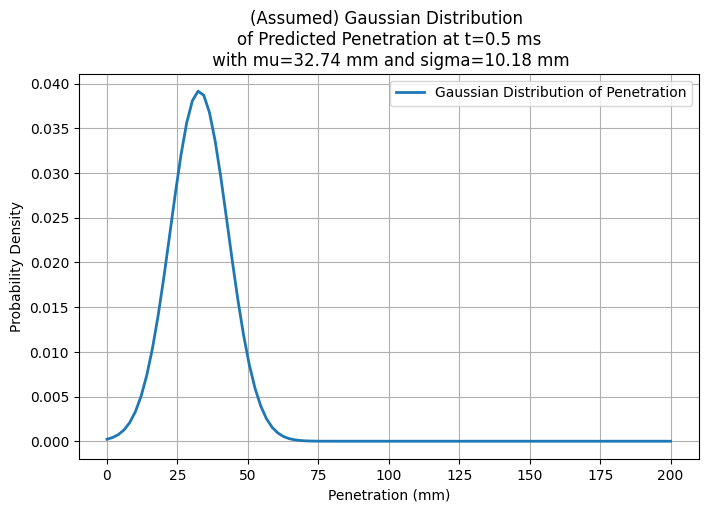

In [57]:
x1 = np.linspace(0,200, 100)
y1 = gaussian_distribution(x1, sigma, mu)
plt.figure(figsize=(8, 5))
plt.plot(x1, y1, linewidth=2, label="Gaussian Distribution of Penetration")
plt.xlabel("Penetration (mm)")
plt.ylabel("Probability Density")
plt.title(f"(Assumed) Gaussian Distribution \nof Predicted Penetration at t={t} ms\n with mu={mu:.2f} mm and sigma={sigma:.2f} mm")
plt.legend()
plt.grid()
plt.show()


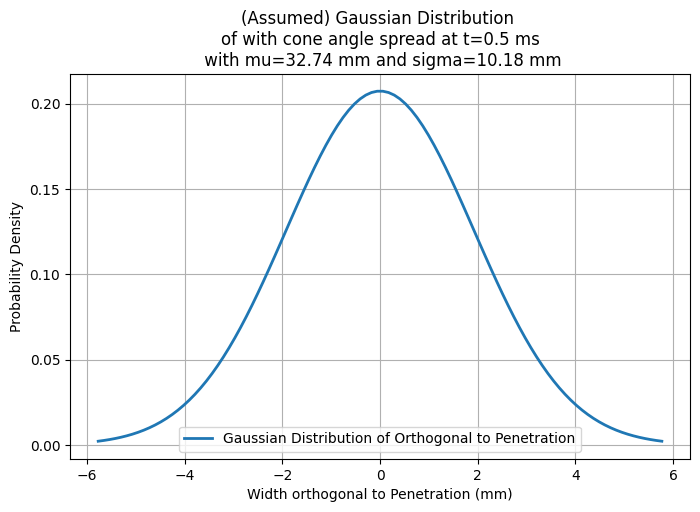

In [58]:
x2 = np.linspace(mu_y-3*sigma_y, mu_y+3*sigma_y, 100)
y2 = gaussian_distribution(x2, sigma_y, mu_y)
plt.figure(figsize=(8, 5))
plt.plot(x2, y2, linewidth=2, label="Gaussian Distribution of Orthogonal to Penetration")
plt.xlabel("Width orthogonal to Penetration (mm)")
plt.ylabel("Probability Density")
plt.title(f"(Assumed) Gaussian Distribution \nof with cone angle spread at t={t} ms\n with mu={mu:.2f} mm and sigma={sigma:.2f} mm")
plt.legend()
plt.grid()
plt.show()

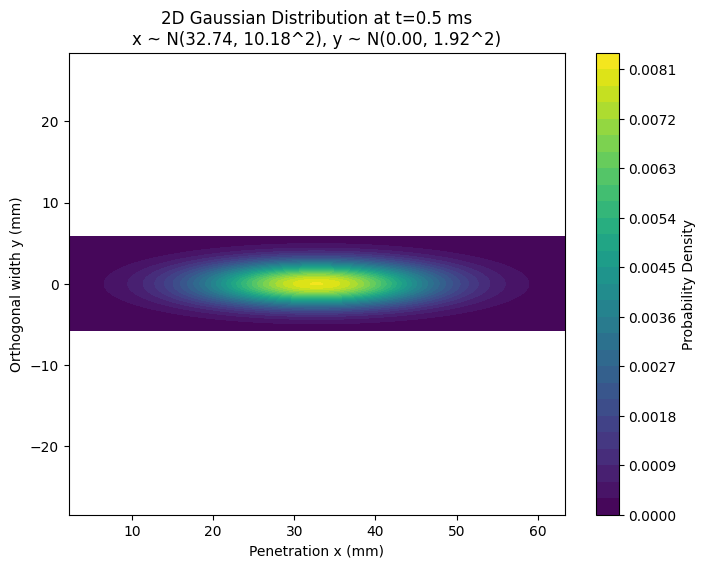

In [59]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_distribution(x, sigma, mu):
    return 1.0 / (sigma * np.sqrt(2 * np.pi)) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

# 1D ranges
x1 = np.linspace(mu - 3*sigma, mu + 3*sigma, 200)
y1 = np.linspace(mu_y - 3*sigma_y, mu_y + 3*sigma_y, 200)

# 2D grid
X, Y = np.meshgrid(x1, y1)

# Independent 2D Gaussian
Z = gaussian_distribution(X, sigma, mu) * gaussian_distribution(Y, sigma_y, mu_y)

plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, Z, levels=30, cmap="viridis")
plt.colorbar(cp, label="Probability Density")
plt.xlabel("Penetration x (mm)")
plt.ylabel("Orthogonal width y (mm)")
plt.title(
    f"2D Gaussian Distribution at t={t} ms\n"
    f"x ~ N({mu:.2f}, {sigma:.2f}^2), y ~ N({mu_y:.2f}, {sigma_y:.2f}^2)"
)
plt.axis("equal")
plt.show()


In [60]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_2d_rotated(X, Y, x0, y0, sigma_axis, sigma_ortho, theta):
    c = np.cos(theta)
    s = np.sin(theta)

    dx = X - x0
    dy = Y - y0

    # world -> local spray coordinates
    u =  c * dx + s * dy
    v = -s * dx + c * dy

    pdf = np.exp(
        -0.5 * ((u / sigma_axis) ** 2 + (v / sigma_ortho) ** 2)
    ) / (2.0 * np.pi * sigma_axis * sigma_ortho)

    return pdf

# grid in physical coordinates, shape must match masks: [H, W] = [y, x]
x = np.arange(0, cylinder_radius + right_padding, grid_size, dtype=float)
y = np.arange(0, cylinder_height + bottom_padding, grid_size, dtype=float)
X, Y = np.meshgrid(x, y, indexing="xy")

theta = toy_raw["tilt_angle_radian"]

# center of Gaussian in world coordinates
x0 = penetration_x_mean
y0 = penetration_y_mean

# along spray axis
sigma_axis = toy_std_np.item()

# orthogonal spread
# if you already have sigma_y, use it directly
sigma_ortho = sigma_y

pdf_2d = gaussian_2d_rotated(
    X, Y,
    x0=x0,
    y0=y0,
    sigma_axis=sigma_axis,
    sigma_ortho=sigma_ortho,
    theta=theta,
)

# normalize on discrete grid so total probability ~= 1
pdf_2d /= (pdf_2d.sum() * grid_size * grid_size)

extent = [x.min(), x.max() + grid_size, y.min(), y.max() + grid_size]


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


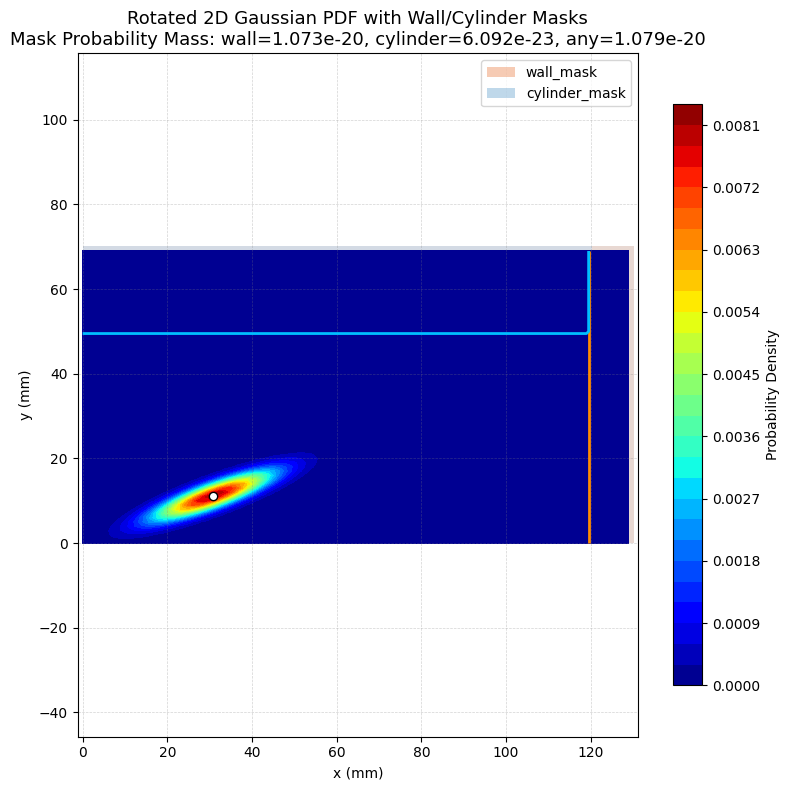

In [61]:
from matplotlib.patches import Patch

p_wall = np.sum(pdf_2d * wall_mask) * (grid_size ** 2)
p_cylinder = np.sum(pdf_2d * cylinder_mask) * (grid_size ** 2)
p_any = np.sum(pdf_2d * np.maximum(wall_mask, cylinder_mask)) * (grid_size ** 2)

fig, ax = plt.subplots(figsize=(8, 8))
contour = ax.contourf(X, Y, pdf_2d, levels=30, cmap="jet")
wall_overlay = np.ma.masked_where(wall_mask == 0, wall_mask)
cylinder_overlay = np.ma.masked_where(cylinder_mask == 0, cylinder_mask)


ax.contour(X, Y, wall_mask, levels=[0.5], colors="darkorange", linewidths=2)
ax.contour(X, Y, cylinder_mask, levels=[0.5], colors="deepskyblue", linewidths=2)


ax.plot(x0, y0, "wo", markersize=6, markeredgecolor="k", label="Gaussian center")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title(
    "Rotated 2D Gaussian PDF with Wall/Cylinder Masks\n"
    f"Mask Probability Mass: wall={p_wall:.3e}, cylinder={p_cylinder:.3e}, any={p_any:.3e}",
    fontsize=13,
)
ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.35)
ax.axis("equal")
ax.set_xlim(0, cylinder_radius + right_padding)
ax.set_ylim(0, cylinder_height + bottom_padding)

ax.imshow(
    wall_overlay,
    cmap="Oranges",
    origin="lower",
    extent=extent,
    alpha=0.18,
    interpolation="none",
    vmin=0,
    vmax=1,
)

ax.imshow(
    cylinder_overlay,
    cmap="Blues",
    origin="lower",
    extent=extent,
    alpha=0.18,
    interpolation="none",
    vmin=0,
    vmax=1,
)
legend_handles = [
    Patch(facecolor=plt.cm.Oranges(0.7), edgecolor="none", alpha=0.30, label="wall_mask"),
    Patch(facecolor=plt.cm.Blues(0.7), edgecolor="none", alpha=0.30, label="cylinder_mask"),
]
ax.legend(handles=legend_handles, loc="upper right")

cbar = plt.colorbar(contour, ax=ax, shrink=0.85)
cbar.set_label("Probability Density")

plt.tight_layout()
plt.show()


In [62]:
print("Wall mask probability mass:", p_wall)
print("Cylinder mask probability mass:", p_cylinder)
print("Any collision probability mass:", p_any)


Wall mask probability mass: 1.0732428937784727e-20
Cylinder mask probability mass: 6.092187547831141e-23
Any collision probability mass: 1.0793350813263038e-20
